# 🏭 Catálogo THC → Base de Datos

Extrae productos del catálogo PDF de [THC Chile](https://thc.cl) usando **visión por computadora + CLIP**.

## ¿Qué hace este notebook?
1. 📥 Descarga el catálogo PDF
2. 📦 Extrae productos individuales de la página 21 con OpenCV
3. 🧠 Clasifica cada producto con CLIP (zero-shot, sin API key)
4. 📁 Exporta resultados a CSV
5. 🔍 Visualiza producto por producto con su clasificación

---
**Instrucciones:** Ejecuta las celdas en orden con `Shift+Enter`

> ⚠️ **Nota:** La primera vez que ejecutes CLIP, descargará el modelo (~1.7 GB).

In [15]:
# ⚙️ Dependencias
!pip install pymupdf pandas openpyxl ipywidgets tqdm -q
# EasyOCR - instalar con pytorch CUDA explícito para evitar conflictos
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118 -q
!pip install easyocr -q!pip install opencv-python-headless -q
!pip install transformers -q



Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -!


In [16]:
import fitz
import pandas as pd
import requests
from PIL import Image, ImageDraw
import io, os, re, json, warnings
from tqdm.notebook import tqdm
from IPython.display import display, Image as IPImage, HTML
import ipywidgets as widgets
import numpy as np
import cv2
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')



---
## 📥 1. Descargar catálogo

In [17]:
URL = "https://thc.cl/archivos/catalogo-thc-chile-2026.pdf"
PDF_PATH = "catalogo-thc-chile-2026.pdf"

if not os.path.exists(PDF_PATH):
    print("Descargando catálogo...")
    r = requests.get(URL, stream=True)
    r.raise_for_status()
    total = int(r.headers.get('content-length', 0))
    with open(PDF_PATH, 'wb') as f:
        for chunk in tqdm(r.iter_content(chunk_size=8192), total=total//8192, unit='KB'):
            f.write(chunk)
    print(f"Descargado: {os.path.getsize(PDF_PATH)/1024/1024:.1f} MB")
else:
    print(f"Ya existe: {os.path.getsize(PDF_PATH)/1024/1024:.1f} MB")

Ya existe: 15.1 MB


In [18]:
pdf = fitz.open(PDF_PATH)
print(f"PDF cargado: {pdf.page_count} páginas")

PDF cargado: 46 páginas


---
## 1. 📦 Extraer productos de la página 21

Extrae las imágenes de cada producto usando detección por contornos con OpenCV.
Renderiza la página a alta resolución y recorta cada producto individualmente.

✅ Imágenes embebidas encontradas: 2
  embebido_01_1392x2034.jpeg: 1392x2034 px
  embebido_02_1392x2034.jpeg: 1392x2034 px

Página renderizada: 3384x4944 px
Contornos encontrados: 1666
Productos detectados: 2
Guardados en productos_pag21/


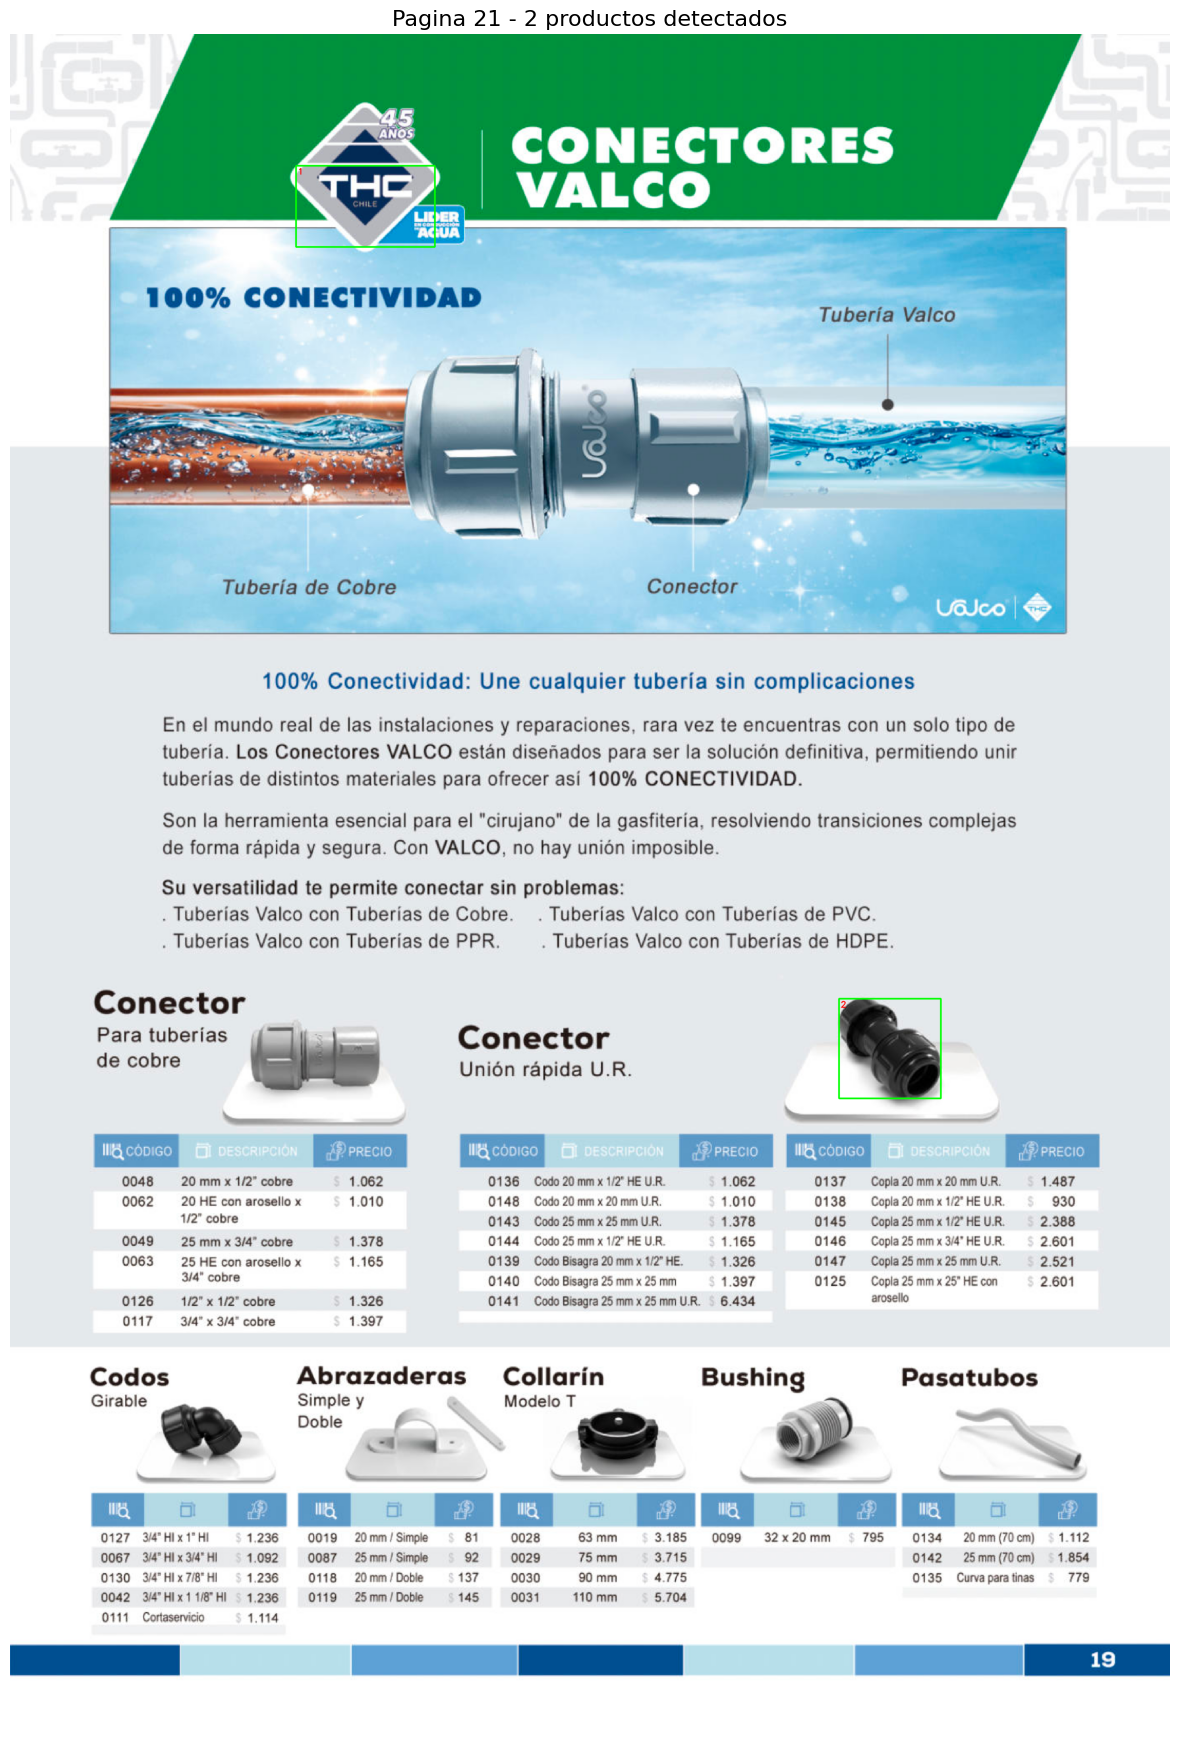

Pagina anotada guardada: pagina_21_anotada.png


In [19]:
PAGE_IDX = 20  # página 21 (0-indexed)
DPI = 350
PROD_DIR = "productos_pag21"
os.makedirs(PROD_DIR, exist_ok=True)

page = pdf[PAGE_IDX]

# --- Intentar extraer imágenes embebidas primero ---
image_list = page.get_images(full=True)
print(f"✅ Imágenes embebidas encontradas: {len(image_list)}")

if image_list:
    for idx, img_info in enumerate(image_list):
        xref = img_info[0]
        base = pdf.extract_image(xref)
        img_bytes = base["image"]
        ext = base["ext"]
        w, h = base["width"], base["height"]
        fname = f"embebido_{idx+1:02d}_{w}x{h}.{ext}"
        fpath = os.path.join(PROD_DIR, fname)
        with open(fpath, "wb") as f:
            f.write(img_bytes)
        print(f"  {fname}: {w}x{h} px")

# --- Renderizar página completa para detección ---
pix = page.get_pixmap(dpi=DPI)
img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
print(f"\nPágina renderizada: {pix.width}x{pix.height} px")

# --- OpenCV: detectar productos por contornos ---
img_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
gray = cv2.cvtColor(img_cv, cv2.COLOR_BGR2GRAY)

# Preprocesamiento
blurred = cv2.GaussianBlur(gray, (7, 7), 0)
thresh = cv2.adaptiveThreshold(
    blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV, 31, 6
)

# Cerrar huecos en contornos
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

# Encontrar contornos
contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f"Contornos encontrados: {len(contours)}")

# --- Filtrar contornos por tamaño y posición ---
W, H = pix.width, pix.height
MIN_W, MIN_H = W * 0.04, H * 0.04
MAX_W, MAX_H = W * 0.50, H * 0.50

boxes = []
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if w < MIN_W or h < MIN_H or w > MAX_W or h > MAX_H:
        continue
    aspect = w / h
    if aspect < 0.3 or aspect > 3.0:
        continue
    boxes.append((x, y, w, h))

# --- Fusionar cajas solapadas (quedarse con la más grande) ---
boxes.sort(key=lambda b: b[2] * b[3], reverse=True)
final_boxes = []
for b in boxes:
    bx, by, bw, bh = b
    overlap = False
    for fb in final_boxes:
        fx, fy, fw, fh = fb
        ix = max(bx, fx)
        iy = max(by, fy)
        iw = min(bx+bw, fx+fw) - ix
        ih = min(by+bh, fy+fh) - iy
        if iw > 0 and ih > 0:
            inter = iw * ih
            area_b = bw * bh
            if inter / area_b > 0.3:
                overlap = True
                break
    if not overlap:
        final_boxes.append(b)

# --- Ordenar de arriba a abajo, izquierda a derecha ---
ROW_TOL = H * 0.03
final_boxes.sort(key=lambda b: (b[1], b[0]))
rows = []
if final_boxes:
    current_row = [final_boxes[0]]
    for b in final_boxes[1:]:
        if abs(b[1] - current_row[-1][1]) < ROW_TOL:
            current_row.append(b)
        else:
            current_row.sort(key=lambda x: x[0])
            rows.append(current_row)
            current_row = [b]
    current_row.sort(key=lambda x: x[0])
    rows.append(current_row)

final_boxes_sorted = []
for row in rows:
    final_boxes_sorted.extend(row)
final_boxes = final_boxes_sorted

print(f"Productos detectados: {len(final_boxes)}")

# --- Extraer y guardar cada producto ---
product_images = []
for i, (x, y, w, h) in enumerate(final_boxes):
    product_img = img.crop((x, y, x+w, y+h))
    fname = f"producto_{i+1:02d}.png"
    fpath = os.path.join(PROD_DIR, fname)
    product_img.save(fpath)
    product_images.append(fpath)

print(f"Guardados en {PROD_DIR}/")

# --- Mostrar resultado final con bounding boxes ---
img_vis = img_cv.copy()
for i, (x, y, w, h) in enumerate(final_boxes):
    cv2.rectangle(img_vis, (x, y), (x+w, y+h), (0, 255, 0), 3)
    cv2.putText(img_vis, str(i+1), (x+5, y+25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

plt.figure(figsize=(16, 22))
plt.imshow(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f"Pagina 21 - {len(final_boxes)} productos detectados", fontsize=16)
plt.show()

# Guardar imagen anotada
Image.fromarray(cv2.cvtColor(img_vis, cv2.COLOR_BGR2RGB)).save("pagina_21_anotada.png")
print("Pagina anotada guardada: pagina_21_anotada.png")

Productos extraidos: 2


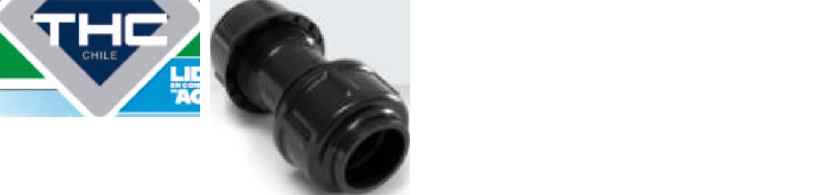

,producto,archivo,tamano_kb
0,Producto 01,producto_01.png,29.5
1,Producto 02,producto_02.png,17.8


In [20]:
print(f"Productos extraidos: {len(product_images)}")
thumb_w = 200
thumbs = []
for fpath in product_images:
    pimg = Image.open(fpath)
    ratio = thumb_w / pimg.width
    thumb_h = int(pimg.height * ratio)
    thumb = pimg.resize((thumb_w, thumb_h))
    thumbs.append(thumb)

# Mostrar en grid de 4 columnas
n_cols = 4
n_rows = (len(thumbs) + n_cols - 1) // n_cols
if thumbs:
    max_h = max(t.height for t in thumbs)
    grid_w = thumb_w * n_cols + (n_cols - 1) * 10
    grid_h = max_h * n_rows + (n_rows - 1) * 10
    grid = Image.new('RGB', (grid_w, grid_h), (255, 255, 255))

    for idx, thumb in enumerate(thumbs):
        col = idx % n_cols
        row = idx // n_cols
        x = col * (thumb_w + 10)
        y = row * (max_h + 10)
        grid.paste(thumb, (x, y))

    display(grid)

# Tabla resumen
df_prods = pd.DataFrame({
    'producto': [f"Producto {i+1:02d}" for i in range(len(product_images))],
    'archivo': [os.path.basename(p) for p in product_images],
    'tamano_kb': [round(os.path.getsize(p)/1024, 1) for p in product_images]
})
display(df_prods)

---
## 2. 🧠 Clasificar productos con CLIP

Usamos el modelo CLIP de OpenAI (zero-shot) para clasificar cada imagen de producto
contra categorias predefinidas del catalogo THC.

**No necesita API key** - corre directamente en la GPU de Colab.

In [21]:
from transformers import CLIPProcessor, CLIPModel
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando: {device.upper()}")

model_name = "openai/clip-vit-large-patch14"

print(f"Cargando {model_name}...")
model = CLIPModel.from_pretrained(model_name).to(device)
processor = CLIPProcessor.from_pretrained(model_name)
n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Modelo listo ({n_params:.0f}M params)")

Usando: CUDA
Cargando openai/clip-vit-large-patch14...


config.json:   0%|          | 0.00/4.52k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.71GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Modelo listo (428M params)


In [22]:
# Categorias del catalogo THC (ajustables)
categories = [
    "taladro electrico", "atornillador electrico", "martillo",
    "llave inglesa", "llave ajustable", "pinza", "alicate",
    "destornillador", "juego de destornilladores",
    "cautin", "soldador", "multimetro", "probador electrico",
    "cable electrico", "cable por metro", "interruptor", "enchufe",
    "ampolleta led", "lampara", "reflector",
    "cinta aislante", "cinta adhesiva",
    "cinta metrica", "huincha de medir", "nivel",
    "sierra manual", "serrucho", "disco de corte",
    "broca", "juego de brocas", "lija", "esmeril",
    "pintura", "brocha", "rodillo para pintar",
    "pegamento", "silicona", "cinta de enmascarar",
    "guante de seguridad", "casco de seguridad", "gafas de seguridad",
    "bateria recargable", "cargador de bateria",
    "extension electrica", "zapatilla electronica",
    "caja de herramientas", "maletin", "organizador",
    "tubo PVC", "conector PVC", "valvula", "llave de paso",
    "sierra circular", "esmeril angular", "lijadora",
    "compresor de aire", "pistola de aire",
    "escala", "escalera", "andamio",
    "carretilla", "palanca", "cortafierro",
]

print(f"{len(categories)} categorias definidas")
print(f"  {', '.join(categories[:10])}...")


63 categorias definidas
  taladro electrico, atornillador electrico, martillo, llave inglesa, llave ajustable, pinza, alicate, destornillador, juego de destornilladores, cautin...


In [23]:
results = []

for fpath in product_images:
    image = Image.open(fpath).convert("RGB")

    inputs = processor(
        text=categories,
        images=image,
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits_per_image[0]
        probs = logits.softmax(dim=0).cpu().numpy()

    # Top-3
    top3_idx = probs.argsort()[::-1][:3]
    top3 = [(categories[i], float(probs[i])) for i in top3_idx]

    results.append({
        'archivo': os.path.basename(fpath),
        'categoria_1': top3[0][0],
        'confianza_1': top3[0][1],
        'categoria_2': top3[1][0],
        'confianza_2': top3[1][1],
        'categoria_3': top3[2][0],
        'confianza_3': top3[2][1],
    })

    print(f"{os.path.basename(fpath)}: {top3[0][0]} ({top3[0][1]:.1%})")

df_clip = pd.DataFrame(results)
print(f"\n{len(df_clip)} productos clasificados")

producto_01.png: huincha de medir (44.9%)
producto_02.png: conector PVC (98.9%)

2 productos clasificados


,archivo,categoria_1,confianza_1,categoria_2,confianza_2,categoria_3,confianza_3
0,producto_01.png,huincha de medir,44.9%,disco de corte,11.1%,gafas de seguridad,9.9%
1,producto_02.png,conector PVC,98.9%,tubo PVC,1.0%,sierra circular,0.0%



RESULTADOS PRODUCTO POR PRODUCTO


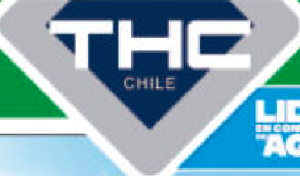

Top 1: huincha de medir (44.9%)
Top 2: disco de corte (11.1%)
Top 3: gafas de seguridad (9.9%)
--------------------------------------------------


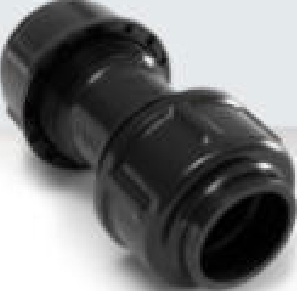

Top 1: conector PVC (98.9%)
Top 2: tubo PVC (1.0%)
Top 3: sierra circular (0.0%)
--------------------------------------------------
Exportado: clasificacion_productos_pag21.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
# Mostrar tabla con formato
styled = df_clip.style.format({
    'confianza_1': '{:.1%}',
    'confianza_2': '{:.1%}',
    'confianza_3': '{:.1%}',
}).background_gradient(subset=['confianza_1'], cmap='RdYlGn')
display(styled)

# Mostrar cada producto con su clasificacion
print("\n" + "="*80)
print("RESULTADOS PRODUCTO POR PRODUCTO")
print("="*80)

for r in results:
    fpath = os.path.join(PROD_DIR, r['archivo'])
    img = Image.open(fpath)
    img.thumbnail((300, 300))
    display(img)
    print(f"Top 1: {r['categoria_1']} ({r['confianza_1']:.1%})")
    print(f"Top 2: {r['categoria_2']} ({r['confianza_2']:.1%})")
    print(f"Top 3: {r['categoria_3']} ({r['confianza_3']:.1%})")
    print("-" * 50)

# Exportar CSV
csv_path = "clasificacion_productos_pag21.csv"
df_clip.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"Exportado: {csv_path}")

try:
    from google.colab import files
    files.download(csv_path)
except ImportError:
    pass

---
## 📊 Resumen

| Archivo | Contenido |
|---------|----------|
| `productos_pag21/producto_XX.png` | Imagenes individuales de cada producto |
| `clasificacion_productos_pag21.csv` | Clasificacion CLIP de cada producto |
| `pagina_21_anotada.png` | Pagina con bounding boxes |

Proximos pasos posibles:
- Ajustar parametros de deteccion si algun producto no se recorto bien
- Agregar mas categorias a CLIP
- Extraer otras paginas del catalogo
- Integrar OCR enfocado en cada recorte para capturar SKU y precio